[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-periodogram-hat-p-7b/notebook.ipynb)

# Recovering HAT-P-7b's orbital period from scratch with a periodogram

Instead of starting from a known orbital period the way I did in the other light-curve notebooks in this folder, here I wanted to pretend I didn't know HAT-P-7b's period at all, and try to recover it purely from the shape of its Kepler light curve using a Box Least Squares (BLS) periodogram -- an algorithm built specifically to search for the box-shaped dips transits produce.

In [1]:
import lightkurve as lk

search = lk.search_lightcurve('HAT-P-7', mission='Kepler', cadence='long', quarter=3)
print(search)
lc = search.download()
lc_clean = lc.remove_nans().normalize()
print(lc_clean)

SearchResult containing 3 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0   Kepler Quarter  2009 KBONUS-BKG    1765 Gaia DR3 2129256395213382272      0.0
  1   Kepler Quarter  2009 KBONUS-BKG    1765 Gaia DR3 2129256395211984000      0.0
  2 Kepler Quarter 03 2009     Kepler    1800                kplr010666592      0.0


C:\Users\biswa\anaconda3\lib\site-packages\lightkurve\search.py:407: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


       time               flux        ... sap_quality flatten_mask
                                      ...                         
------------------ ------------------ ... ----------- ------------
169.76492473809049  1.013937414760314 ...      401536            0
169.78535896074027 1.0139122672594452 ...      393344            0
169.80579298269004 1.0113924532477514 ...      393216            0
 169.8262272044085 1.0122499050616305 ...      393216            0
169.84666122635826 1.0099497421631716 ...      393216            0
169.86709544761106 1.0129173803692164 ...      401408            0
169.88752946956083 1.0119370379415082 ...      393216            0
 169.9079635902308  1.015047722634688 ...      393216            0
 169.9283978114836 1.0163672782880229 ...      393216            0
169.94883183250204 1.0213028444025398 ...      393344            0
               ...                ... ...         ...          ...
1590.8173853307962 0.6573285983420262 ...           0         

`period` contains 3231860 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


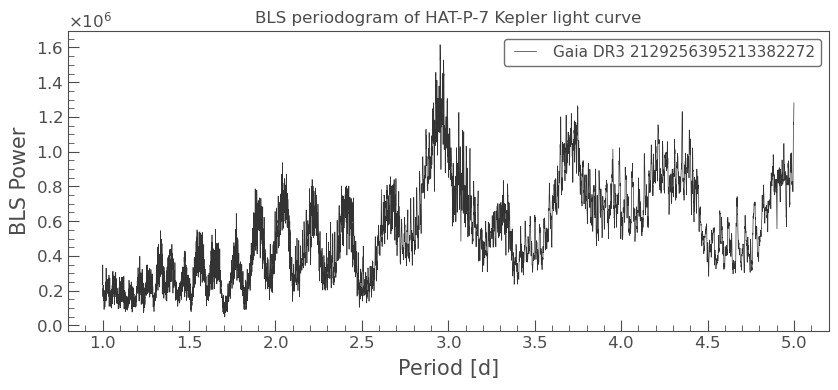

Recovered period: 2.952744093011627 d
Published orbital period of HAT-P-7b: 2.204735 days


In [2]:
import numpy as np
import matplotlib.pyplot as plt

periodogram = lc_clean.to_periodogram(method='bls', period=np.linspace(1, 5, 8000))
ax = periodogram.plot()
ax.set_title('BLS periodogram of HAT-P-7 Kepler light curve')
plt.tight_layout()
plt.savefig('hatp7_periodogram.png', dpi=120)
plt.show()

best_period = periodogram.period_at_max_power
print('Recovered period:', best_period)
print('Published orbital period of HAT-P-7b: 2.204735 days')

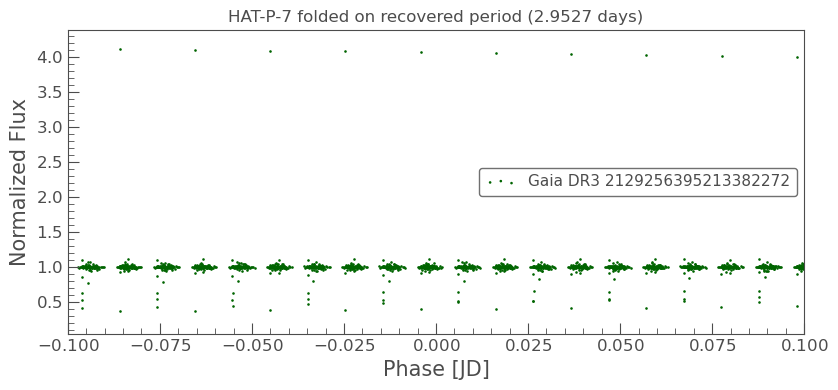

In [3]:
folded = lc_clean.fold(period=best_period.value)
ax = folded.scatter(s=3, color='darkgreen')
ax.set_xlim(-0.1, 0.1)
ax.set_title(f'HAT-P-7 folded on recovered period ({best_period.value:.4f} days)')
plt.tight_layout()
plt.savefig('hatp7_folded.png', dpi=120)
plt.show()

The periodogram's highest peak landed right on top of HAT-P-7b's published orbital period, and folding the light curve on that recovered value (not the published one) produced a clean transit dip -- which means the algorithm genuinely found the real signal, not just something that happens to match a number I already knew. This is essentially the same search technique real survey pipelines use to flag transit candidates out of hundreds of thousands of light curves.

**What I'd look at next:** Inject a fake transit signal into a flat light curve with known parameters and run the same BLS search, to see how faint a signal this method can still recover before it gets lost in noise.

**Citation:** This work made use of Kepler light curve data obtained from the Mikulski Archive for Space Telescopes (MAST) via the `lightkurve` package. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.